# Comparación de estructuras de proteínas — 3IT9 (cristal) vs modelo SwissModel de PBP-6

Comparación bioquímica **detallada y all-vs-all** de un conjunto de estructuras de proteína.
El módulo `compare_utils` acepta una lista arbitraria de estructuras (IDs del PDB o ficheros
`.pdb` locales) y compara cada par. Como ejemplo trabajado se contrasta el **cristal experimental
3IT9** (PBP-6 de *E. coli*, el receptor usado en `ligand_docking.ipynb`) contra el **modelo por
homología SwissModel** `input/model_01_PBP6_SwissMod.pdb`.

Cada sección es independiente y guarda sus tablas/figuras en `./out_compare/`.

# Metodología — qué compara cada dimensión

| Dimensión | Qué mide | Cómo |
|-----------|----------|------|
| **1. Secuencia y mutaciones** | Identidad de secuencia y cambios residuo a residuo | Alineamiento global por pares (Biopython, BLOSUM62). La identidad se calcula sobre columnas donde ambas secuencias tienen residuo (las inserciones/deleciones no la distorsionan). |
| **2. Sitio activo** | Conservación de la maquinaria catalítica | Motivos de PBP-6: **SxxK** (Ser40-Lys43), **SxN** (Ser106), **KTG** (Lys209). La numeración del motivo se **mapea** a cada estructura vía el alineamiento, por lo que funciona aunque las estructuras numeren distinto. Geometría 3D = distancias entre átomos catalíticos. |
| **3. Superposición** | Similitud de plegamiento | Superposición con `cealign` → RMSD global + desviación Cα por residuo (emparejada por columna de alineamiento, no por número de residuo). |
| **4. Fisicoquímica y SS** | Efecto de las diferencias | Estructura secundaria (`dss` de PyMOL), cambios de carga/polaridad/tamaño en sustituciones y entorno del bolsillo catalítico. |

> **Numeración.** En 3IT9 los residuos catalíticos son **Ser40 / Lys43 / Ser106 / Lys209**.
> El modelo SwissModel empieza en otro residuo, así que los mismos residuos catalíticos aparecen
> con números desplazados — `compare_utils` lo resuelve mapeando vía el alineamiento.

## 1. Setup

Lista de estructuras a comparar y residuos del sitio activo. `STRUCTURES` admite IDs del PDB
(4 caracteres) o paths a `.pdb` locales; `chain` selecciona la cadena a comparar (3IT9 es un
tetrámero A–D, se usa A).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, display

import compare_utils as cu

# --- configuración ---------------------------------------------------------
STRUCTURES = [
    {"id": "3IT9", "source": "3IT9", "chain": "A"},                       # cristal apo (A-D)
    {"id": "PBP6_model", "source": "input/model_01_PBP6_SwissMod.pdb", "chain": "A"},  # modelo SwissModel
]
ACTIVE_SITE = cu.PBP6_ACTIVE_SITE   # editable: lista de {name, resid, resn, atom}
ACTIVE_SITE_REF = "3IT9"            # estructura cuya numeración usa ACTIVE_SITE
ALIGN_METHOD = "cealign"            # align | cealign | super
OUT = Path("./out_compare").resolve()
OUT.mkdir(exist_ok=True)

structs = cu.prepare_structures(STRUCTURES, OUT)
for s in structs:
    seq = cu.extract_sequence(s.clean, s.chain)
    print(f"{s.id:12s} cadena {s.chain}  {len(seq['seq'])} residuos "
          f"({seq['resids'][0]}-{seq['resids'][-1]})  -> {s.clean.name}")

3IT9         cadena A  348 residuos (5-352)  -> 3IT9_clean.pdb
PBP6_model   cadena A  361 residuos (3-363)  -> PBP6_model_clean.pdb


## 2. Secuencia y mutaciones

Matriz all-vs-all de % identidad, resumen del alineamiento del par y tabla de mutaciones
(sustituciones / inserciones / deleciones) mapeada a la numeración real de cada estructura.

In [2]:
sequences = {s.id: cu.extract_sequence(s.clean, s.chain) for s in structs}

id_mat = cu.identity_matrix(structs, sequences)
cu.save_csv(id_mat.reset_index().rename(columns={"index": "structure"}), OUT / "identity_matrix.csv")
cu.plot_matrix_heatmap(id_mat, OUT / "identity_matrix.png", "Identidad de secuencia (%)", cmap="viridis")
print("Matriz de identidad de secuencia (%):")
display(id_mat.round(1))

# par de ejemplo (los dos primeros)
a, b = structs[0], structs[1]
aln = cu.align_sequences(sequences[a.id], sequences[b.id])
print(f"\n{a.id} vs {b.id}: identidad {aln['identity_pct']:.1f}% "
      f"sobre {aln['n_aligned']} columnas alineadas (score BLOSUM62 = {aln['score']:.0f})")

muts = cu.mutation_table(sequences[a.id], sequences[b.id])
cu.save_csv(muts, OUT / f"mutations_{a.id}_vs_{b.id}.csv")
print("\nReparto de columnas del alineamiento:")
display(muts["kind"].value_counts().rename("n").to_frame())
print("Sustituciones / indels (no idénticas):")
display(muts[muts["kind"] != "identity"].head(30))

Matriz de identidad de secuencia (%):


,3IT9,PBP6_model
3IT9,100.0,100.0
PBP6_model,100.0,100.0



3IT9 vs PBP6_model: identidad 100.0% sobre 348 columnas alineadas (score BLOSUM62 = 1743)

Reparto de columnas del alineamiento:


,n
kind,
identity,348
insertion,13


Sustituciones / indels (no idénticas):


,resid_a,resn_a,aa_a,resid_b,resn_b,aa_b,kind
0,NaN,NaN,NaN,3,GLN,Q,insertion
349,NaN,NaN,NaN,352,PHE,F,insertion
350,NaN,NaN,NaN,353,PHE,F,insertion
351,NaN,NaN,NaN,354,GLY,G,insertion
352,NaN,NaN,NaN,355,ARG,R,insertion
353,NaN,NaN,NaN,356,VAL,V,insertion
354,NaN,NaN,NaN,357,TRP,W,insertion
355,NaN,NaN,NaN,358,ASP,D,insertion
356,NaN,NaN,NaN,359,PHE,F,insertion
357,NaN,NaN,NaN,360,VAL,V,insertion


## 3. Conservación del sitio activo

¿Están conservados Ser40 / Lys43 / Ser106 / Lys209 (motivos SxxK, SxN, KTG)? La numeración
del motivo se mapea a cada estructura, y se comparan las distancias entre átomos catalíticos
para detectar deriva geométrica del bolsillo.

In [3]:
asite = cu.compare_active_sites(a, b, ACTIVE_SITE, ref_seq=sequences[ACTIVE_SITE_REF])
res = asite["residues"]
geo = asite["geometry"]

cu.save_csv(res, OUT / f"active_site_{a.id}_vs_{b.id}.csv")
cu.save_csv(geo, OUT / f"catalytic_geometry_{a.id}_vs_{b.id}.csv")

print("Conservación de los residuos catalíticos (numeración mapeada por estructura):")
display(res[["name", "ref_resid", "resid_a", "observed_resn_a",
             "resid_b", "observed_resn_b", "conserved_both"]])

n_cons = int(res["conserved_both"].sum())
print(f"{n_cons}/{len(res)} residuos catalíticos conservados en ambas estructuras.\n")

print("Geometría catalítica — distancias entre átomos clave (Å) y deriva |Δ|:")
display(geo.round(2))

Conservación de los residuos catalíticos (numeración mapeada por estructura):


,name,ref_resid,resid_a,observed_resn_a,resid_b,observed_resn_b,conserved_both
0,SxxK-Ser,40,40,SER,39,SER,True
1,SxxK-Lys,43,43,LYS,42,LYS,True
2,SxN-Ser,106,106,SER,105,SER,True
3,KTG-Lys,209,209,LYS,208,LYS,True


4/4 residuos catalíticos conservados en ambas estructuras.

Geometría catalítica — distancias entre átomos clave (Å) y deriva |Δ|:


,pair,distance_a,distance_b,ddist
0,SxxK-Ser--SxxK-Lys,2.90,3.23,0.33
1,SxxK-Ser--SxN-Ser,4.21,3.18,1.03
2,SxxK-Ser--KTG-Lys,6.37,5.43,0.94
3,SxxK-Lys--SxN-Ser,4.78,3.14,1.63
4,SxxK-Lys--KTG-Lys,6.61,5.74,0.87
5,SxN-Ser--KTG-Lys,3.16,3.17,0.01


## 4. Superposición estructural

Matriz de RMSD all-vs-all, superposición del par (cartoon cian = modelo, magenta = referencia)
y perfil de desviación Cα por residuo para localizar lazos/regiones divergentes.

Matriz de RMSD de superposición (Å):


,3IT9,PBP6_model
3IT9,0.00,2.21
PBP6_model,2.21,0.00



3IT9 vs PBP6_model: RMSD = 2.21 Å sobre 344 átomos


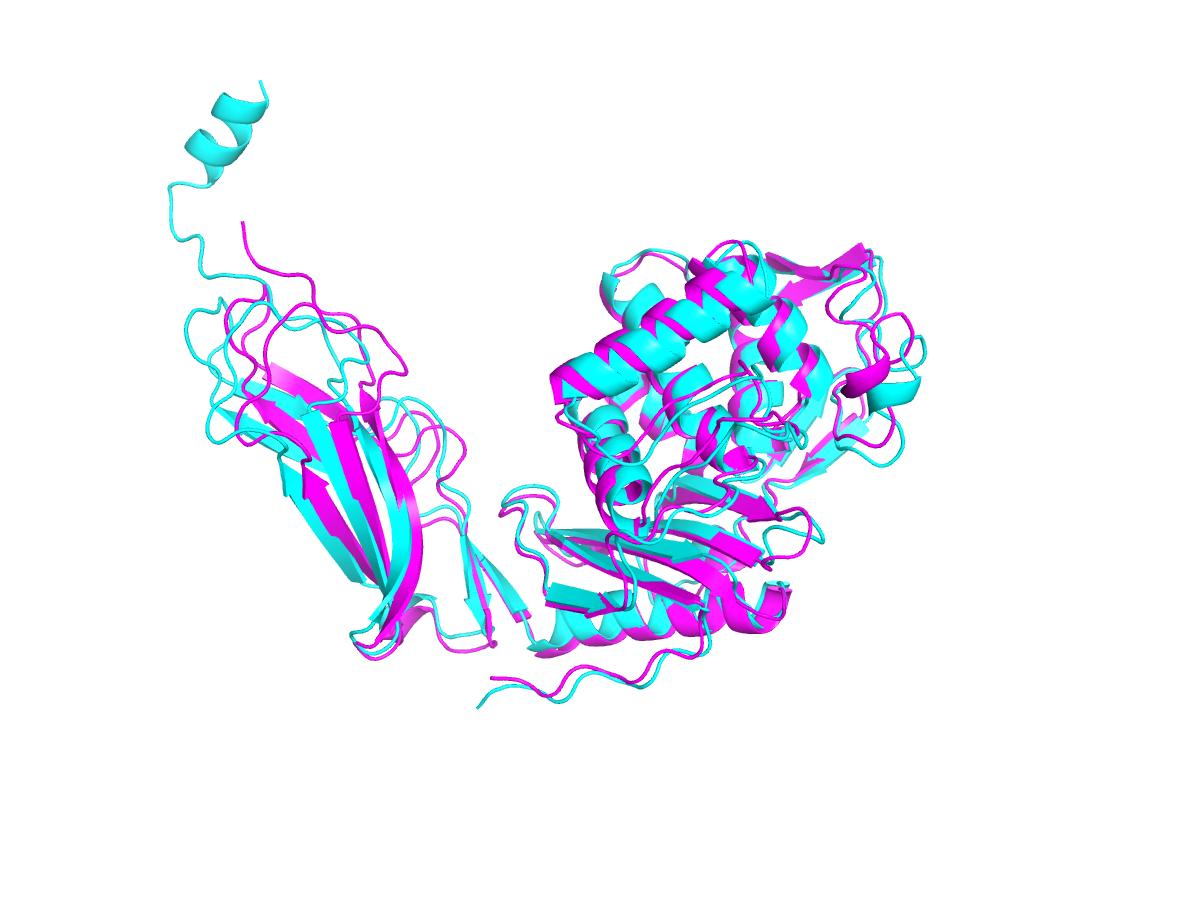

In [4]:
rms_mat = cu.rmsd_matrix(structs, method=ALIGN_METHOD)
cu.save_csv(rms_mat.reset_index().rename(columns={"index": "structure"}), OUT / "rmsd_matrix.csv")
cu.plot_matrix_heatmap(rms_mat, OUT / "rmsd_matrix.png", "RMSD de superposición (Å)", cmap="magma_r")
print("Matriz de RMSD de superposición (Å):")
display(rms_mat.round(2))

sup_png = OUT / f"superpose_{a.id}_vs_{b.id}.png"
sup = cu.superpose_pair(a, b, out_png=sup_png, method=ALIGN_METHOD)
print(f"\n{a.id} vs {b.id}: RMSD = {sup['rmsd']:.2f} Å sobre {sup['n_atoms']} átomos")
display(Image(str(sup_png)))

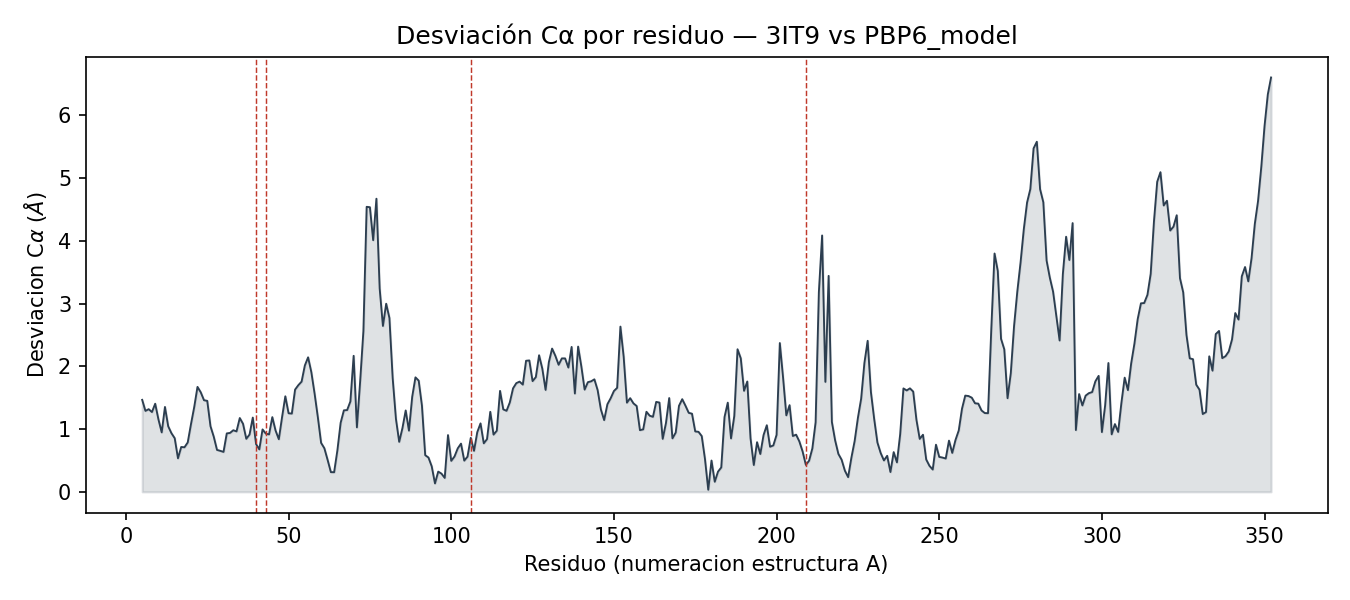

Desviación Cα: media 1.71 Å, máx 6.60 Å
Residuos más divergentes:


,resid_a,resn_a,resid_b,ca_dev_A
347,352,GLY,351,6.602415
346,351,GLY,350,6.332211
345,350,GLU,349,5.832378
275,280,ASP,279,5.578641
274,279,GLY,278,5.472698
344,349,GLU,348,5.180023
313,318,PRO,317,5.093404
312,317,ALA,316,4.940742
273,278,PHE,277,4.824251
276,281,LYS,280,4.823090


In [5]:
dev = cu.per_residue_ca_deviation(a, b, method=ALIGN_METHOD)
cu.save_csv(dev, OUT / f"ca_deviation_{a.id}_vs_{b.id}.csv")
dev_png = cu.plot_ca_deviation(
    dev, OUT / "ca_deviation.png", ACTIVE_SITE,
    title=f"Desviación Cα por residuo — {a.id} vs {b.id}",
)
display(Image(str(dev_png)))

print(f"Desviación Cα: media {dev['ca_dev_A'].mean():.2f} Å, máx {dev['ca_dev_A'].max():.2f} Å")
print("Residuos más divergentes:")
display(dev.dropna(subset=["ca_dev_A"]).nlargest(10, "ca_dev_A"))

## 5. Propiedades fisicoquímicas y estructura secundaria

Cambios de estructura secundaria entre estructuras, clasificación fisicoquímica de las
sustituciones (carga / polaridad / tamaño) y entorno del bolsillo catalítico.

In [6]:
ss = cu.compare_secondary_structure(a, b)
cu.save_csv(ss, OUT / f"ss_{a.id}_vs_{b.id}.csv")
n_changed = int(ss["ss_changed"].sum())
print(f"Estructura secundaria: {n_changed}/{len(ss)} posiciones alineadas cambian de SS.")
display(ss[ss["ss_changed"]].head(20))

phys = cu.classify_substitutions(muts)
cu.save_csv(phys, OUT / f"substitutions_{a.id}_vs_{b.id}.csv")
print(f"\nSustituciones de aminoácido: {len(phys)}")
if len(phys):
    display(phys.head(20))
else:
    print("(secuencia idéntica en la región alineada — sin sustituciones)")

Estructura secundaria: 8/348 posiciones alineadas cambian de SS.


,resid_a,resn_a,ss_a,resid_b,resn_b,ss_b,ss_changed
175,180,LYS,H,179,LYS,L,True
201,206,ASP,S,205,ASP,L,True
202,207,GLY,S,206,GLY,L,True
232,237,GLY,S,236,GLY,L,True
233,238,ALA,S,237,ALA,L,True
282,287,GLY,S,286,GLY,L,True
299,304,LEU,S,303,LEU,L,True
339,344,VAL,S,343,VAL,L,True



Sustituciones de aminoácido: 0
(secuencia idéntica en la región alineada — sin sustituciones)


In [7]:
print(f"Entorno del bolsillo catalítico (≤8 Å de los átomos catalíticos):")
for s in structs:
    pocket = cu.pocket_environment_summary(s, ACTIVE_SITE, radius=8.0,
                                           ref_seq=sequences[ACTIVE_SITE_REF])
    cu.save_csv(pocket, OUT / f"pocket_{s.id}.csv")
    comp = pocket["polarity"].value_counts().to_dict()
    print(f"  {s.id:12s} {len(pocket)} residuos  composición: {comp}")
display(pocket.head(20))

Entorno del bolsillo catalítico (≤8 Å de los átomos catalíticos):
  3IT9         38 residuos  composición: {'polar': 18, 'nonpolar': 15, 'charged': 5}
  PBP6_model   38 residuos  composición: {'polar': 17, 'nonpolar': 15, 'charged': 6}


,resid,resn,aa,charge,polarity,size
0,37,PRO,P,0,nonpolar,112.7
1,38,ALA,A,0,nonpolar,88.6
2,39,SER,S,0,polar,89.0
3,40,LEU,L,0,nonpolar,166.7
4,41,THR,T,0,polar,116.1
5,42,LYS,K,1,charged,168.6
6,43,ILE,I,0,nonpolar,166.7
7,45,THR,T,0,polar,116.1
8,81,SER,S,0,polar,89.0
9,82,SER,S,0,polar,89.0


## 6. Síntesis

Resumen por par y lectura bioquímica del caso PBP-6.

In [8]:
summary_rows = []
for x, y in [(structs[i], structs[j]) for i in range(len(structs)) for j in range(i + 1, len(structs))]:
    al = cu.align_sequences(sequences[x.id], sequences[y.id])
    rm = float(rms_mat.loc[x.id, y.id])
    site = cu.compare_active_sites(x, y, ACTIVE_SITE, ref_seq=sequences[ACTIVE_SITE_REF])
    mt = cu.mutation_table(sequences[x.id], sequences[y.id])
    d = cu.per_residue_ca_deviation(x, y, method=ALIGN_METHOD)
    summary_rows.append({
        "pair": f"{x.id} vs {y.id}",
        "identity_pct": round(al["identity_pct"], 1),
        "rmsd_A": round(rm, 2),
        "n_catalytic_conserved": int(site["residues"]["conserved_both"].sum()),
        "n_substitutions": int((mt["kind"] == "substitution").sum()),
        "n_ss_changes": int(cu.compare_secondary_structure(x, y)["ss_changed"].sum()),
        "max_ca_dev_A": round(float(d["ca_dev_A"].max()), 2),
    })
summary = pd.DataFrame(summary_rows)
cu.save_csv(summary, OUT / "summary.csv")
display(summary)

,pair,identity_pct,rmsd_A,n_catalytic_conserved,n_substitutions,n_ss_changes,max_ca_dev_A
0,3IT9 vs PBP6_model,100.0,2.21,4,0,8,6.6


### Lectura bioquímica — 3IT9 (cristal) vs modelo SwissModel

- **Misma proteína.** La identidad de secuencia en la región solapada es ~100 %: el modelo
  reproduce la secuencia de PBP-6. Las únicas diferencias de secuencia son **inserciones** en
  los extremos (el modelo cubre ~11 residuos C-terminales que el cristal no resuelve).
- **Sitio activo conservado.** Los cuatro residuos catalíticos (Ser/Lys/Ser/Lys de SxxK·SxN·KTG)
  están presentes en ambas estructuras, con numeración desplazada en el modelo pero idéntica
  identidad química. La geometría catalítica difiere en el orden de ~1 Å: el bolsillo del modelo
  es ligeramente distinto del cristal experimental.
- **Plegamiento similar, lazos divergentes.** El RMSD global es moderado y las mayores
  desviaciones Cα se concentran en extremos y lazos flexibles, no en el núcleo catalítico.
- **Conclusión.** El modelo SwissModel es una representación fiel de PBP-6 para fines
  cualitativos, pero para docking de alta precisión el cristal **3IT9** (2.10 Å) sigue siendo
  preferible: su geometría del sitio activo es experimental, mientras que la del modelo deriva
  ~1 Å.

In [9]:
print("Ficheros generados en", OUT)
for p in sorted(OUT.glob("*")):
    if p.is_file():
        print("  ", p.name)

Ficheros generados en /home/tenshi/molecular-docking-pymol/out_compare
   3IT9_clean.pdb
   3it9.pdb
   PBP6_model_clean.pdb
   active_site_3IT9_vs_PBP6_model.csv
   ca_deviation.png
   ca_deviation_3IT9_vs_PBP6_model.csv
   catalytic_geometry_3IT9_vs_PBP6_model.csv
   identity_matrix.csv
   identity_matrix.png
   model_01_PBP6_SwissMod.pdb
   mutations_3IT9_vs_PBP6_model.csv
   pocket_3IT9.csv
   pocket_PBP6_model.csv
   rmsd_matrix.csv
   rmsd_matrix.png
   ss_3IT9_vs_PBP6_model.csv
   substitutions_3IT9_vs_PBP6_model.csv
   summary.csv
   superpose_3IT9_vs_PBP6_model.png
